# Mcardiac preprocessing

This public notebook was migrated from the audited read-only research source. 
Configure paths in `config.yaml` before execution. Time is metadata and is never a model input.


In [ ]:
from pathlib import Path
import yaml

DATASET = 'Mcardiac'
CWD = Path.cwd().resolve()
EXPERIMENT_DIR = CWD if (CWD / "config.yaml").is_file() else CWD / "experiments" / DATASET
REPO_ROOT = EXPERIMENT_DIR.parents[1]
import sys
sys.path.append(str(REPO_ROOT / "src"))

CONFIG = yaml.safe_load(
    (EXPERIMENT_DIR / "config.yaml").read_text(encoding="utf-8")
)

def experiment_path(value):
    path = Path(value)
    return path if path.is_absolute() else (EXPERIMENT_DIR / path).resolve()

DATA_ROOT = experiment_path(CONFIG["data_root"])
RUN_ROOT = experiment_path(CONFIG["run_root"])
CHECKPOINT_ROOT = experiment_path(CONFIG["checkpoint_root"])
SCANVI_DIR = experiment_path(CONFIG["scanvi_dir"])
SCANVI_ADATA = SCANVI_DIR / "adata.h5ad"
LR_PAIRS = experiment_path(CONFIG["lr_pairs_path"])
DIFF_MAP = experiment_path(CONFIG["diff_map_path"]) if "diff_map_path" in CONFIG else None
DATA_ROOT.mkdir(parents=True, exist_ok=True)
RUN_ROOT.mkdir(parents=True, exist_ok=True)
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)


In [ ]:
import scanpy as sc

In [ ]:
adata9 = sc.read_h5ad(str(DATA_ROOT / 'Mosta_heart_9h.h5ad'))
adata11 = sc.read_h5ad(str(DATA_ROOT / 'Mosta_heart_11h_full.h5ad'))
adata9.layers['counts'] = adata9.X.copy()
print(adata9)
print(adata11)

AnnData object with n_obs × n_vars = 44644 × 17649
    obs: 'area', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'louvain', 'transf_anno_E95', 'mapped_celltype', 'head_or_body', 'heart_region', 'sample'
    obsm: '3d_align_spatial', 'X_pca', 'bbox', 'global_align_spatial', 'spatial', 'spatial_aligned'
    layers: 'counts'
AnnData object with n_obs × n_vars = 51671 × 21717
    obs: 'area', 'n_genes_by_counts', 'total_counts', 'n_counts', 'louvain', 'transf_anno', 'ManualAnnotation', 'slice_id', 'embryo_id', 'mapped_celltype'
    obsm: 'X_pca', 'bbox', 'spatial', 'z_correction'
    layers: 'counts'


/tmp/ipykernel_3426599/937150789.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z_num = z_num.bfill(axis=1).iloc[:, 0]
<conda-env>/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
<conda-env>/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)


sp11 shape = (51671, 3)
adata11 z range: 10.0 ~ 690.0
adata11 unique z: [ 10.  20.  30.  40.  50.  60.  70.  80.  90. 110. 120. 130. 140. 150.
 160. 170. 180. 190. 200. 210.]
sp9 shape  = (44644, 3)
sp11 shape = (51671, 3)
adata11 z range: 10.0 ~ 690.0

===== merged adata =====
AnnData object with n_obs × n_vars = 96315 × 21792
    obs: 'area', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'louvain', 'transf_anno_E95', 'mapped_celltype', 'head_or_body', 'heart_region', 'sample', 'stage', 'transf_anno', 'ManualAnnotation', 'slice_id', 'embryo_id', 'dataset'
    obsm: 'spatial_3d'
    layers: 'counts'
merged n_vars = 21792
merged counts shape = (96315, 21792)
merged spatial_3d shape = (96315, 3)


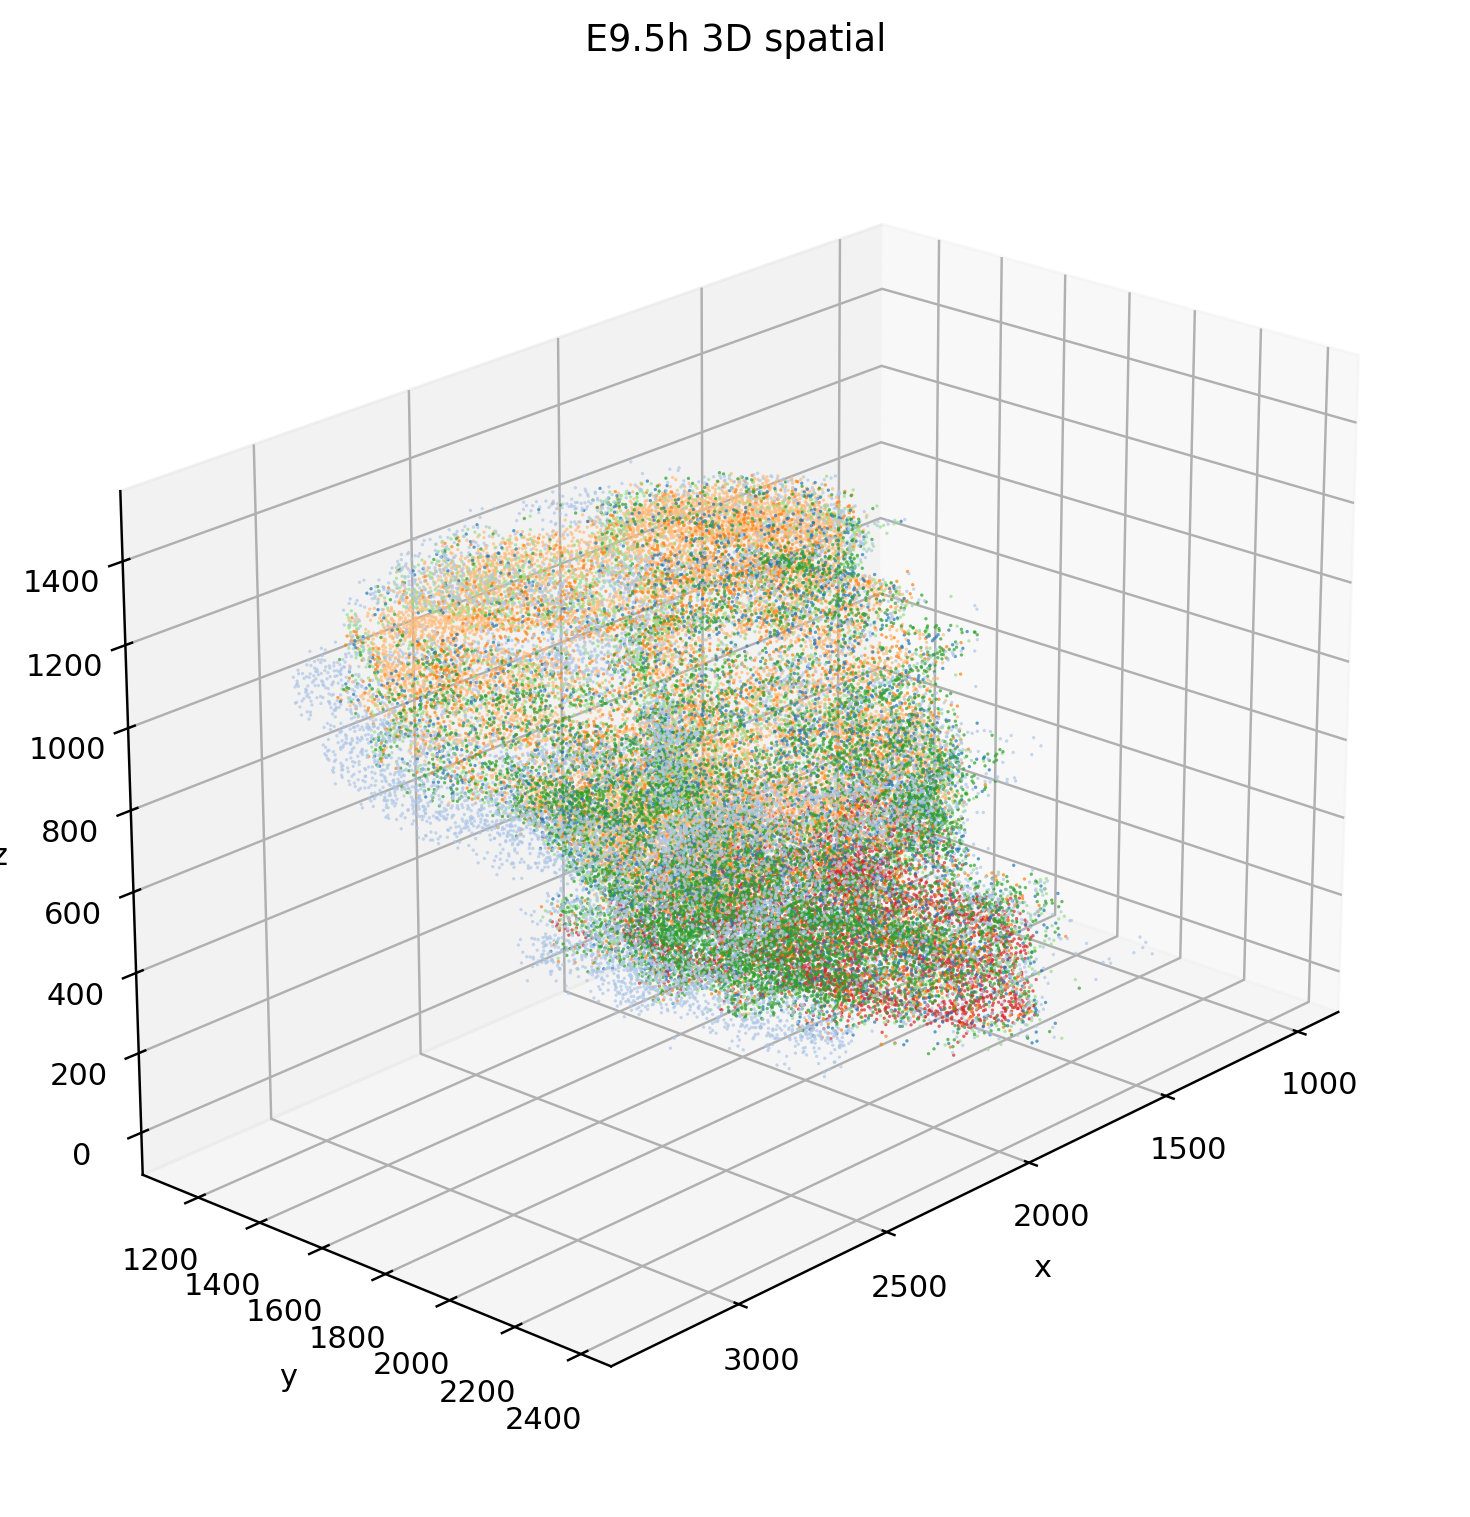

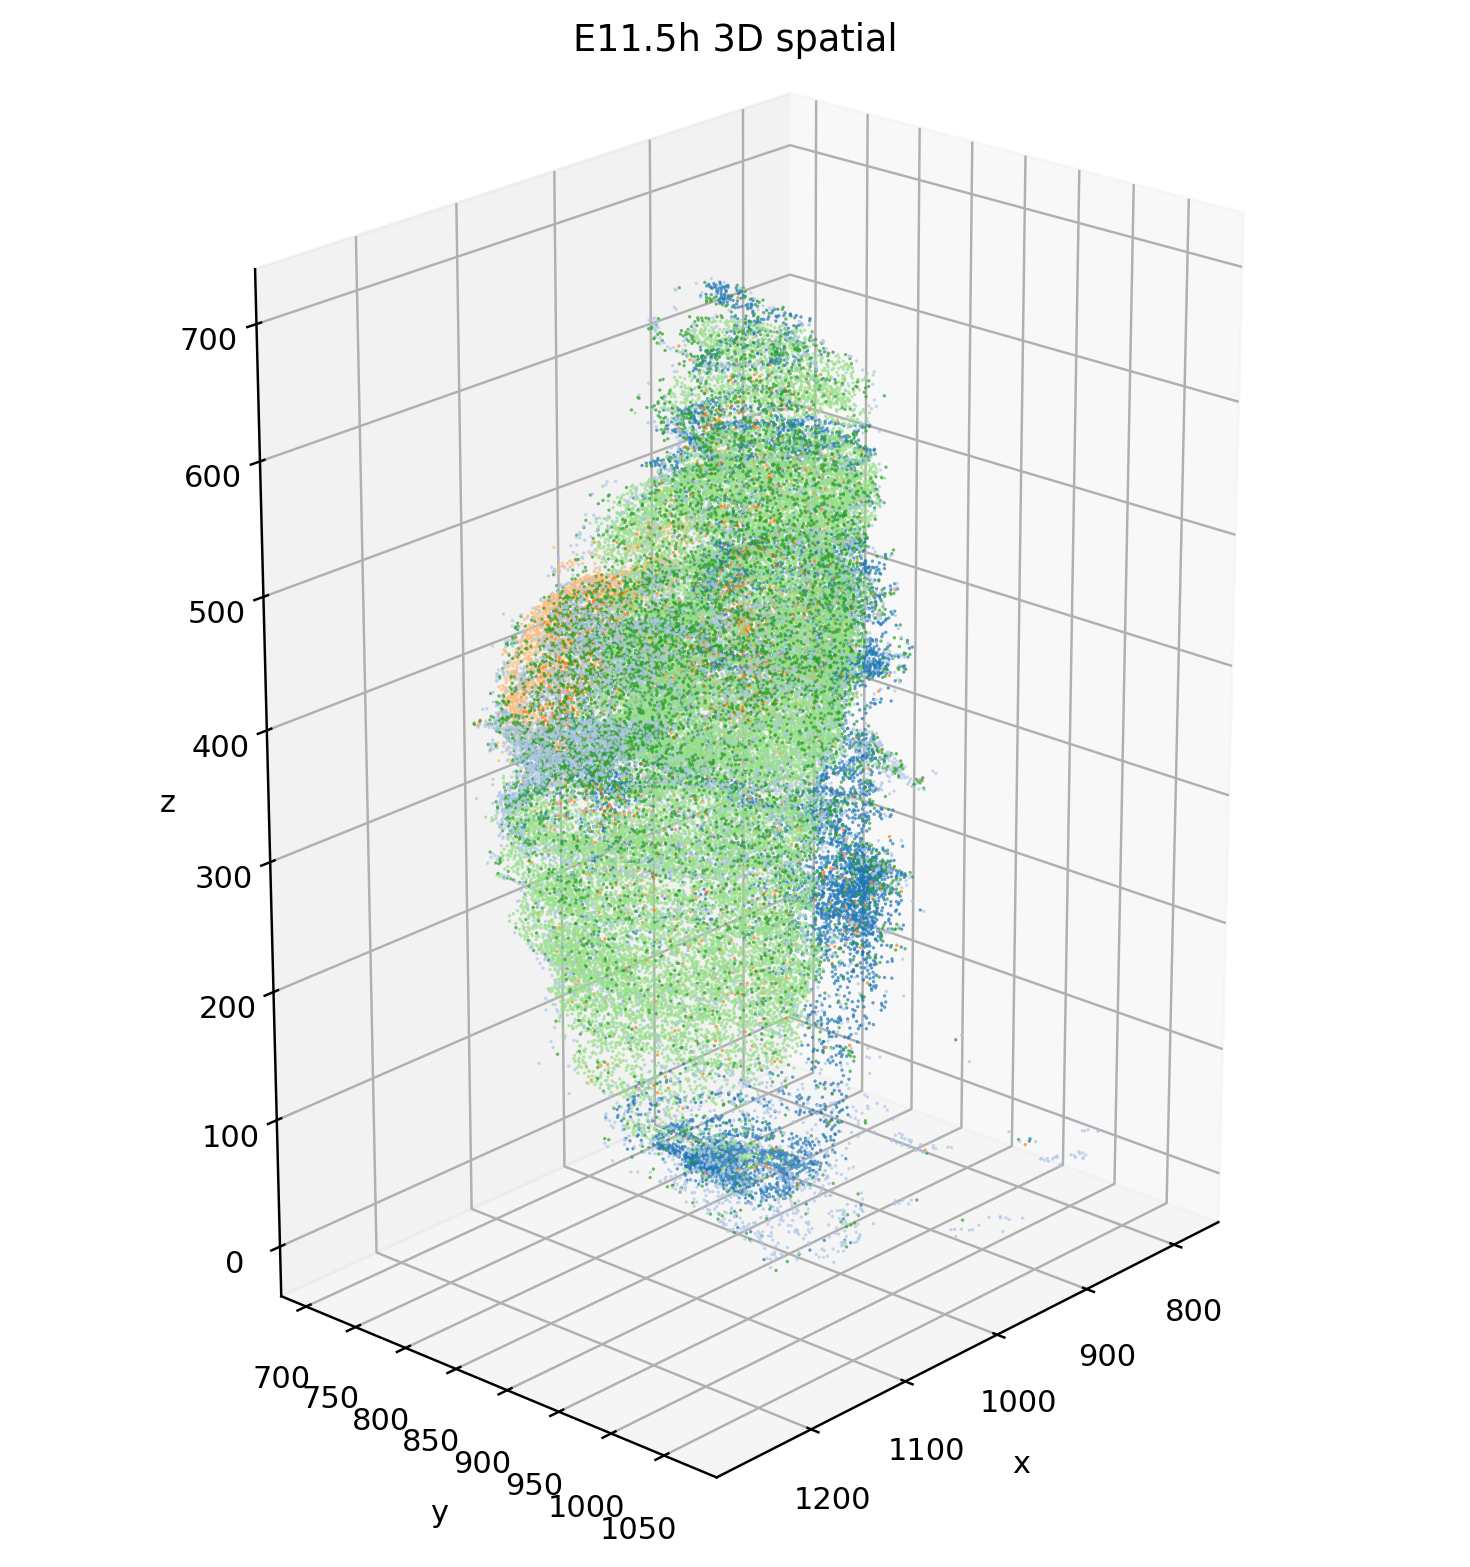

In [ ]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from pathlib import Path

outdir = Path(str(DATA_ROOT / 'merge_E9.5h_E11.5h'))
outdir.mkdir(parents=True, exist_ok=True)

def to_csr(x):
    if sp.issparse(x):
        return x.tocsr()
    return sp.csr_matrix(np.asarray(x))

def get_counts(a):
    if "counts" in a.layers:
        return to_csr(a.layers["counts"])
    return to_csr(a.X)

def extract_z_from_slice_name(
    a,
    orig_col="orig.ident",
    z_scale=1.0,
    use_real_z=True,
):
    if orig_col not in a.obs.columns:
        raise KeyError(f"adata11.obs  {orig_col}")

    s = a.obs[orig_col].astype(str)

    z_num = s.str.extract(r"(?:S(\d+)$|_z(\d+)$)", expand=True)

    z_num = z_num.bfill(axis=1).iloc[:, 0]

    if z_num.isna().any():
        bad = s[z_num.isna()].unique()[:10]
        raise ValueError(
            f" {orig_col}  z ，: {list(bad)}"
        )

    z_num = z_num.astype(float)

    if use_real_z:
        z = z_num.to_numpy(dtype=np.float32) * float(z_scale)
    else:
        # ，
        uniq = np.sort(z_num.unique())
        z_map = {v: i * float(z_scale) for i, v in enumerate(uniq)}
        z = z_num.map(z_map).to_numpy(dtype=np.float32)

    if len(z) != a.n_obs:
        raise ValueError(f"z  {len(z)} != n_obs {a.n_obs}")

    return z

def build_working_adata(a, spatial3d, stage_name):
    counts = get_counts(a)
    obs = a.obs.copy()
    var = a.var.copy()

    out = ad.AnnData(
        X=counts,
        obs=obs,
        var=var,
        dtype=counts.dtype
    )
    out.layers["counts"] = counts.copy()
    out.obsm["spatial_3d"] = np.asarray(spatial3d, dtype=np.float32)
    out.obs["stage"] = stage_name

    if "mapped_celltype" in out.obs.columns:
        out.obs["mapped_celltype"] = out.obs["mapped_celltype"].astype(str)

    return out

def make_palette(categories):
    cmaps = [plt.get_cmap("tab20"), plt.get_cmap("tab20b"), plt.get_cmap("tab20c")]
    colors = []
    for cmap in cmaps:
        colors.extend([cmap(i) for i in range(cmap.N)])
    if len(categories) > len(colors):
        extra = plt.get_cmap("hsv")
        colors.extend([extra(i / len(categories)) for i in range(len(categories) - len(colors))])
    return {cat: colors[i] for i, cat in enumerate(categories)}

def plot_3d_by_cat(
    adata,
    color_col,
    title,
    save,
    basis="spatial_3d",
    s=1.5,
    alpha=0.70,
    elev=22,
    azim=42,
    legend=False,
):
    xyz = np.asarray(adata.obsm[basis], dtype=float)
    vals = adata.obs[color_col].astype(str).fillna("NA")
    cats = pd.Categorical(vals).categories.tolist()
    pal = make_palette(cats)

    fig = plt.figure(figsize=(8, 7), dpi=220)
    ax = fig.add_subplot(111, projection="3d")

    vals_np = vals.to_numpy()
    for cat in cats:
        mask = vals_np == cat
        ax.scatter(
            xyz[mask, 0],
            xyz[mask, 1],
            xyz[mask, 2],
            s=s,
            alpha=alpha,
            c=[pal[cat]],
            linewidths=0,
            label=cat
        )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title(title)
    ax.view_init(elev=elev, azim=azim)

    # 
    x_min, y_min, z_min = xyz.min(axis=0)
    x_max, y_max, z_max = xyz.max(axis=0)
    ax.set_box_aspect((x_max - x_min, y_max - y_min, max(z_max - z_min, 1e-6)))

    if legend and len(cats) <= 25:
        ax.legend(
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=False,
            markerscale=4
        )

    plt.tight_layout()
    plt.savefig(save, bbox_inches="tight")
    plt.show()
    plt.close()

adata9 = adata9.copy()
adata11 = adata11.copy()

adata9.var_names_make_unique()
adata11.var_names_make_unique()
adata9.obs_names_make_unique()
adata11.obs_names_make_unique()

# =========================
# 3)  3D spatial
# =========================
# ---- 9.5h:  3d_align_spatial
if "3d_align_spatial" not in adata9.obsm:
    raise KeyError("adata9.obsm  '3d_align_spatial'")

sp9 = np.asarray(adata9.obsm["3d_align_spatial"], dtype=np.float32)
if sp9.ndim != 2 or sp9.shape[1] < 3:
    raise ValueError(f"adata9.obsm['3d_align_spatial'] : {sp9.shape}")
sp9 = sp9[:, :3]

# ---- 11.5h: spatial + z from orig.ident
if "spatial" not in adata11.obsm:
    raise KeyError("adata11.obsm  'spatial'")

xy11 = np.asarray(adata11.obsm["spatial"], dtype=np.float32)
if xy11.ndim != 2 or xy11.shape[1] < 2:
    raise ValueError(f"adata11.obsm['spatial'] : {xy11.shape}")

z11 = extract_z_from_slice_name(
    adata11,
    orig_col="slice_id",
    z_scale=10.0,
    use_real_z=True,   # True: ；False: 
)

sp11 = np.c_[xy11[:, 0], xy11[:, 1], z11].astype(np.float32)

print("sp11 shape =", sp11.shape)
print("adata11 z range:", float(z11.min()), "~", float(z11.max()))
print("adata11 unique z:", np.sort(np.unique(z11))[:20])

print("sp9 shape  =", sp9.shape)
print("sp11 shape =", sp11.shape)
print("adata11 z range:", float(z11.min()), "~", float(z11.max()))

# =========================
# 4) 
# =========================
adata9w = build_working_adata(adata9, sp9, "E9.5h")
adata11w = build_working_adata(adata11, sp11, "E11.5h")

# =========================
# 5)  gene 
#     X=counts  outer join， 0
# =========================
adata_merge = ad.concat(
    [adata9w, adata11w],
    axis=0,
    join="outer",
    label="dataset",
    keys=["E9.5h", "E11.5h"],
    index_unique="-",
    merge="first",
    fill_value=0
)

#  counts layer 
adata_merge.layers["counts"] = adata_merge.X.copy()

#  spatial_3d 
if "spatial_3d" not in adata_merge.obsm:
    adata_merge.obsm["spatial_3d"] = np.vstack([
        adata9w.obsm["spatial_3d"],
        adata11w.obsm["spatial_3d"]
    ]).astype(np.float32)

#  mapped_celltype
if "mapped_celltype" in adata_merge.obs.columns:
    adata_merge.obs["mapped_celltype"] = adata_merge.obs["mapped_celltype"].astype(str)

print("\n===== merged adata =====")
print(adata_merge)
print("merged n_vars =", adata_merge.n_vars)
print("merged counts shape =", adata_merge.layers["counts"].shape)
print("merged spatial_3d shape =", adata_merge.obsm["spatial_3d"].shape)

plot_3d_by_cat(
    adata9w,
    color_col="mapped_celltype",
    title="E9.5h 3D spatial",
    save=outdir / "E9.5h_3d_spatial_by_mapped_celltype.png",
    s=1.2,
    alpha=0.70,
    legend=False
)

plot_3d_by_cat(
    adata11w,
    color_col="mapped_celltype",
    title="E11.5h 3D spatial",
    save=outdir / "E11.5h_3d_spatial_by_mapped_celltype.png",
    s=1.2,
    alpha=0.70,
    legend=False
)

[E9.5h] n=44644 min=[1006.21515 1110.9135     0.     ] max=[3251.309  2396.6145 1460.    ]
[E11.5h] n=51671 min=[783.2836  701.61865  10.     ] max=[1262.8486 1072.0902  690.    ]


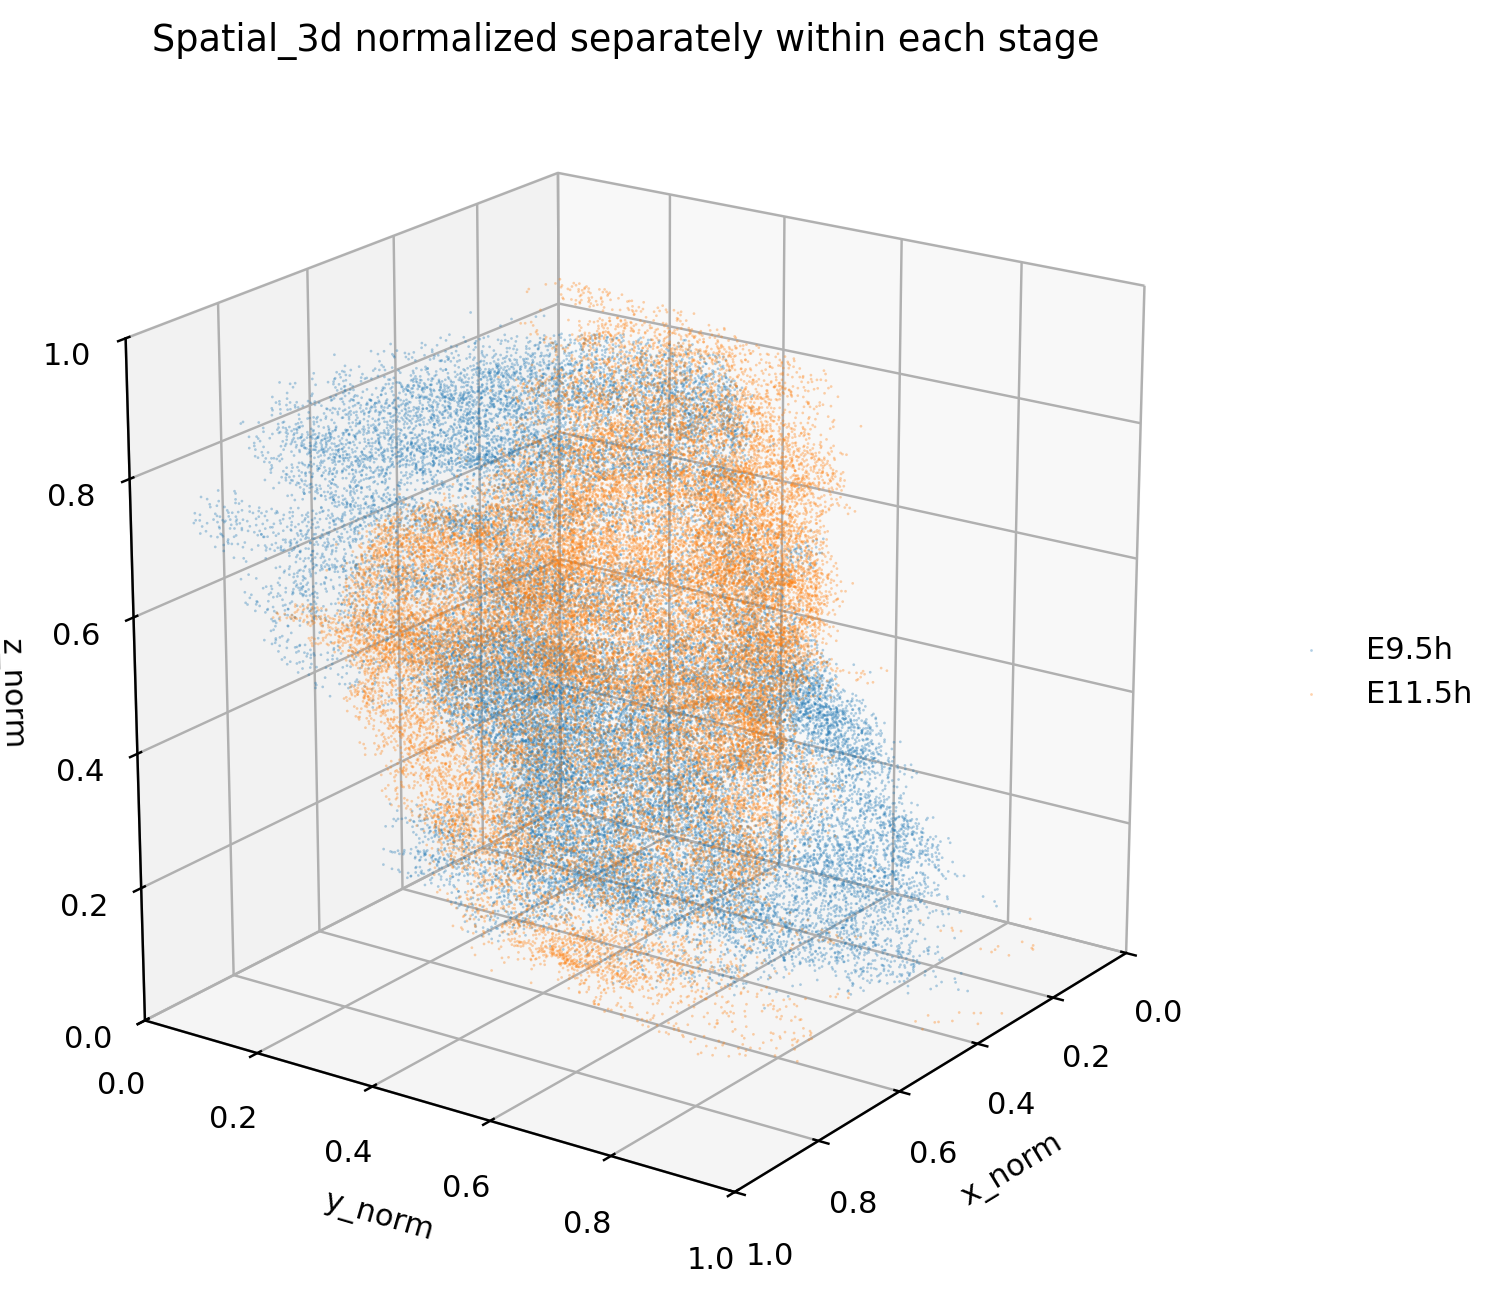

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def normalize_xyz_minmax(xyz, eps=1e-8):
    xyz = np.asarray(xyz, dtype=np.float32)
    mn = xyz.min(axis=0)
    mx = xyz.max(axis=0)
    rg = np.maximum(mx - mn, eps)
    xyz_norm = (xyz - mn) / rg
    return xyz_norm, mn, mx

def normalize_spatial3d_within_stage(
    adata,
    basis="spatial_3d",
    stage_col="stage",
    out_key="spatial_3d_stage_norm",
):
    if basis not in adata.obsm:
        raise KeyError(f"adata.obsm['{basis}'] ")
    if stage_col not in adata.obs.columns:
        raise KeyError(f"adata.obs['{stage_col}'] ")

    xyz = np.asarray(adata.obsm[basis], dtype=np.float32)
    if xyz.ndim != 2 or xyz.shape[1] < 3:
        raise ValueError(f"adata.obsm['{basis}'] : {xyz.shape}")

    xyz = xyz[:, :3]
    stage = adata.obs[stage_col].astype(str).to_numpy()

    xyz_norm_all = np.full_like(xyz, np.nan, dtype=np.float32)
    stats = {}

    for st in pd.unique(stage):
        mask = (stage == st)
        xyz_st = xyz[mask]
        xyz_st_norm, mn, mx = normalize_xyz_minmax(xyz_st)
        xyz_norm_all[mask] = xyz_st_norm
        stats[st] = {
            "min": mn,
            "max": mx,
            "n_cells": int(mask.sum())
        }
        print(f"[{st}] n={mask.sum()} min={mn} max={mx}")

    adata.obsm[out_key] = xyz_norm_all
    return adata, stats

def plot_stage_normalized_overlay(
    adata,
    basis="spatial_3d_stage_norm",
    stage_col="stage",
    sample_n_per_stage=None,
    s=1.0,
    alpha=0.35,
    elev=20,
    azim=35,
    title="Stage-wise normalized spatial_3d in one coordinate system",
):
    if basis not in adata.obsm:
        raise KeyError(f"adata.obsm['{basis}'] ")
    if stage_col not in adata.obs.columns:
        raise KeyError(f"adata.obs['{stage_col}'] ")

    xyz = np.asarray(adata.obsm[basis], dtype=np.float32)
    stage = adata.obs[stage_col].astype(str).to_numpy()
    stages = pd.unique(stage)

    cmap = plt.get_cmap("tab10")
    color_map = {st: cmap(i % 10) for i, st in enumerate(stages)}

    fig = plt.figure(figsize=(7, 6), dpi=220)
    ax = fig.add_subplot(111, projection="3d")

    rng = np.random.RandomState(0)

    for st in stages:
        idx = np.where(stage == st)[0]
        if sample_n_per_stage is not None and len(idx) > sample_n_per_stage:
            idx = rng.choice(idx, size=sample_n_per_stage, replace=False)

        ax.scatter(
            xyz[idx, 0],
            xyz[idx, 1],
            xyz[idx, 2],
            s=s,
            alpha=alpha,
            linewidths=0,
            color=color_map[st],
            label=st
        )

    ax.set_xlabel("x_norm")
    ax.set_ylabel("y_norm")
    ax.set_zlabel("z_norm")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_zlim(0, 1)
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(title)
    ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))

    plt.tight_layout()
    plt.show()


# =========================
# 
# =========================
adata, norm_stats = normalize_spatial3d_within_stage(
    adata_merge,
    basis="spatial_3d",
    stage_col="stage",
    out_key="spatial_3d_stage_norm"
)

plot_stage_normalized_overlay(
    adata,
    basis="spatial_3d_stage_norm",
    stage_col="stage",
    sample_n_per_stage=30000,   #  None
    s=0.8,
    alpha=0.35,
    elev=20,
    azim=35,
    title="Spatial_3d normalized separately within each stage"
)

In [ ]:
adata

AnnData object with n_obs × n_vars = 96315 × 21792
    obs: 'area', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'louvain', 'transf_anno_E95', 'mapped_celltype', 'head_or_body', 'heart_region', 'sample', 'stage', 'transf_anno', 'ManualAnnotation', 'slice_id', 'embryo_id', 'dataset'
    obsm: 'spatial_3d', 'spatial_3d_stage_norm'
    layers: 'counts'

In [ ]:
key = "spatial_3d_stage_norm"

if key not in adata.obsm:
    raise KeyError(f"adata.obsm['{key}'] ")

xyz = np.asarray(adata.obsm[key], dtype=np.float32)
if xyz.ndim != 2 or xyz.shape[1] < 3:
    raise ValueError(f"adata.obsm['{key}'] : {xyz.shape}")

adata.obs["cx_aligned"] = xyz[:, 0]
adata.obs["cy_aligned"] = xyz[:, 1]
adata.obs["cz_aligned"] = xyz[:, 2]

print(adata.obs[["cx_aligned", "cy_aligned", "cz_aligned"]].head())

                 cx_aligned  cy_aligned  cz_aligned
cell_420-E9.5h     0.769158    0.655954    0.315068
cell_3170-E9.5h    0.487510    0.088654    0.808219
cell_3176-E9.5h    0.487092    0.105320    0.808219
cell_3189-E9.5h    0.493378    0.062063    0.808219
cell_3193-E9.5h    0.495346    0.127355    0.808219


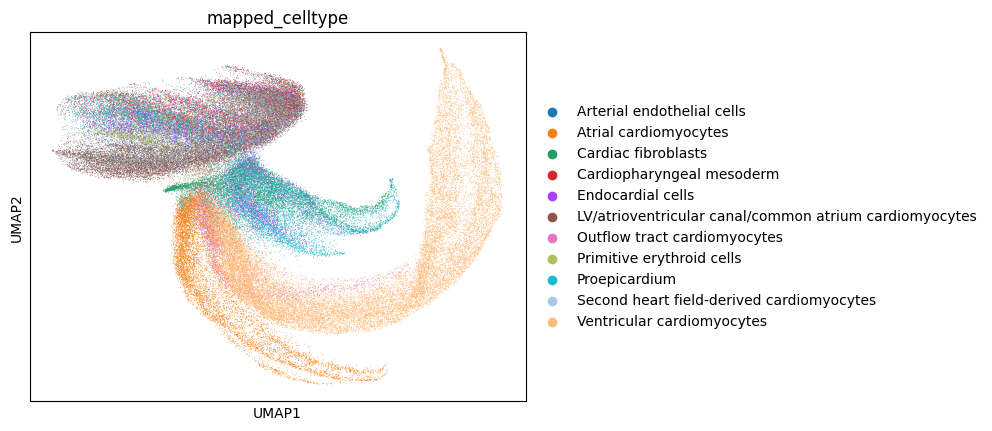

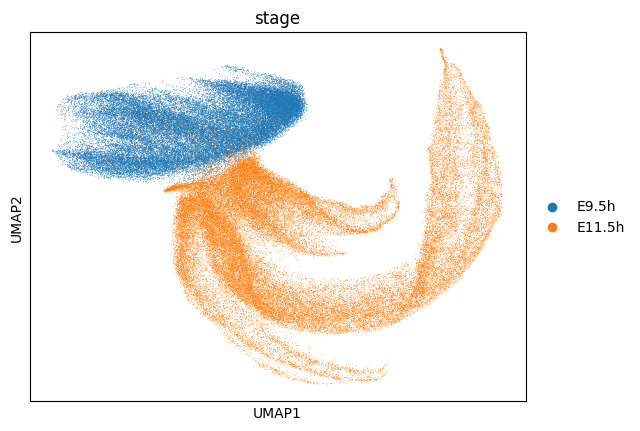

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.tl.pca(adata, n_comps=50)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color="mapped_celltype", wspace=0.4)
sc.pl.umap(adata, color="stage", wspace=0.4)

In [ ]:
import scvi, os
scvi.model.SCANVI.setup_anndata(
    adata,
    layer="counts",
    labels_key="mapped_celltype",
    unlabeled_category="Unknown",   
    batch_key="stage"
)
model = scvi.model.SCANVI(adata)
model.train()

INFO     Training for 83 epochs.                                                                                   


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
<conda-env>/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be 

Training:   0%|          | 0/83 [00:00<?, ?it/s]

In [ ]:
model_dir = SCANVI_DIR


In [ ]:
SCVI_LATENT_KEY = CONFIG.get("latent_key", "X_scanVI")
adata.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()
adata.obsm[SCVI_LATENT_KEY].shape


(96315, 10)

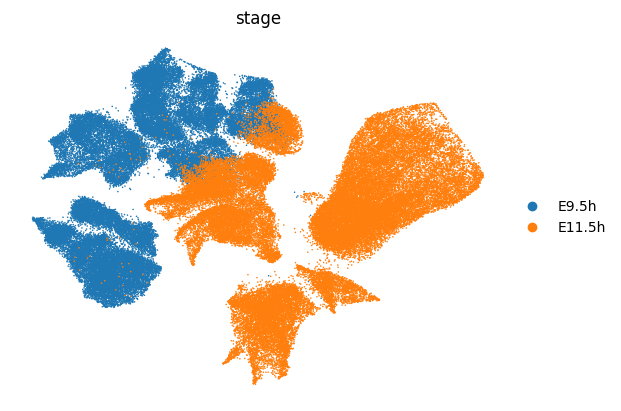

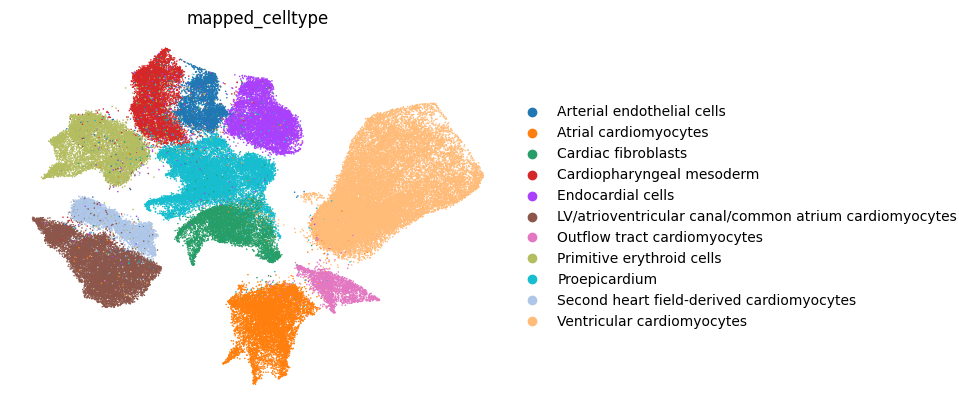

AnnData object with n_obs × n_vars = 96315 × 21792
    obs: 'area', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'louvain', 'transf_anno_E95', 'mapped_celltype', 'head_or_body', 'heart_region', 'sample', 'stage', 'transf_anno', 'ManualAnnotation', 'slice_id', 'embryo_id', 'dataset', 'cx_aligned', 'cy_aligned', 'cz_aligned', '_scvi_batch', '_scvi_labels'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'mapped_celltype_colors', 'stage_colors', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'spatial_3d', 'spatial_3d_stage_norm', 'X_pca', 'X_umap', 'X_scanVI'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [ ]:
sc.pp.neighbors(adata, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(adata)
sc.pl.umap(adata, color=["stage"],frameon=False,size = 5,)
sc.pl.umap(adata,color=["mapped_celltype"],frameon=False,size = 5,)
adata

In [ ]:
model.save(model_dir, overwrite=True, save_anndata=True)
print(f"Saved model-ready AnnData: {SCANVI_ADATA}")


Saved model-ready AnnData: <repo>/experiments/Mcardiac/artifacts/checkpoints/scanvi/adata.h5ad
